# Notebook to make Figure 11 (Appendix A): Underlying vs. Detected Simulated Population

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
import seaborn as sns
sns.set_palette('colorblind')

## Setup

Load data

**NOTE**: These data are from Miller+2024 (https://arxiv.org/abs/2401.05613). They are excluded from this repository but are available upon request.


In [2]:
with open('../data/true_underlying_population_det_draws.json', 'r') as f:
    detected = json.load(f)
with open('../data/true_underlying_population_inj_draws.json', 'r') as f:
    underlying = json.load(f)

Format spins for plotting

In [3]:
to_plot = {
    'underlying':{k:np.asarray(list(v.values())) for k,v in underlying.items()},
    'detected':{k:np.asarray(list(v.values())) for k,v in detected.items()}
}

for k,v in to_plot.items():
    
    chi1 = np.sqrt(v['s1x']**2 + v['s1y']**2 + v['s1z']**2)
    chi2 = np.sqrt(v['s2x']**2 + v['s2y']**2 + v['s2z']**2)

    v['chi1'] = chi1
    v['chi2'] = chi2
    v['cos_theta1'] = v['s1z']/chi1
    v['cos_theta2'] = v['s2z']/chi2
    v['phi1'] = np.arctan(v['s1y']/v['s1x']) 
    v['phi2'] = np.arctan(v['s1y']/v['s2x']) 

## Make figure

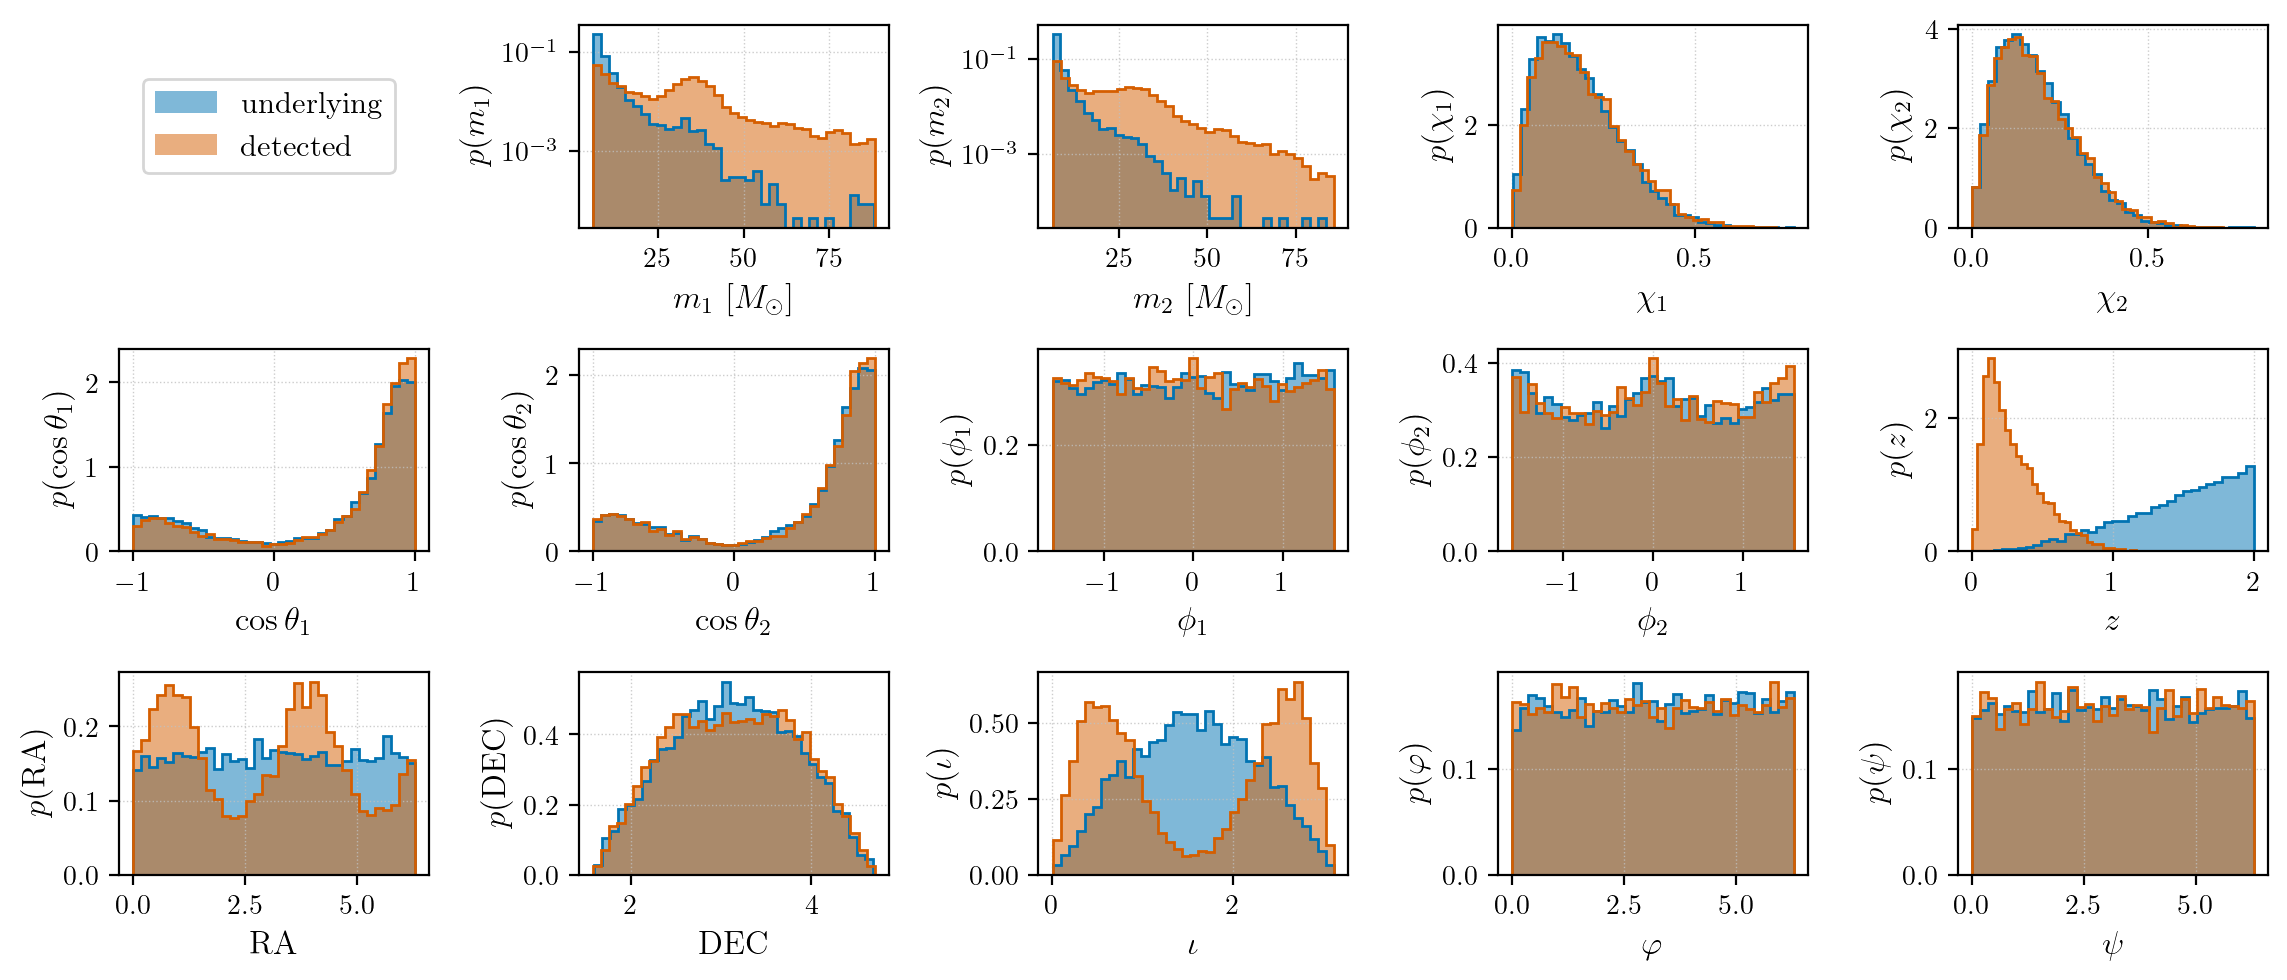

In [4]:
fig, axes = plt.subplots(3,5, figsize=(15/1.3,7/1.4))

params = ['m1', 'm2', 'chi1', 'chi2', 'cos_theta1', 'cos_theta2', 'phi1', 'phi2', 'z', 'ra', 'dec', 'inc', 'phase', 'pol']
labels = [r'm_1', r'm_2', r'\chi_1', r'\chi_2', r'\cos\theta_1',r'\cos\theta_2', r'\phi_1', r'\phi_2', 
             r'z', '\mathrm{RA}', '\mathrm{DEC}', r'\iota', r'\varphi', '\psi']

for i, k in enumerate(params):

    ax = axes.flatten()[i+1]
    nbins = 35
    
    ax.hist(to_plot['underlying'][k], density=True, label='underlying', bins=nbins, alpha=0.5, color='C0')
    ax.hist(to_plot['underlying'][k], density=True, bins=nbins, histtype='step', color='C0')

    ax.hist(to_plot['detected'][k], density=True, label='detected', bins=nbins, alpha=0.5, color='C3')
    ax.hist(to_plot['detected'][k], density=True, bins=nbins, histtype='step', color='C3')


    ax.set_xlabel(fr'${labels[i]}$', fontsize=12)
    ax.set_ylabel(fr'$p({labels[i]})$', fontsize=12)

    ax.grid(ls=':', lw=0.5, color='silver', alpha=0.8)

axes[0][0].set_visible(False)

axes[0][1].set_xlabel(fr'$m_1~[M_\odot]$', fontsize=12)
axes[0][2].set_xlabel(fr'$m_2~[M_\odot]$', fontsize=12)
axes[0][1].set_yscale('log')
axes[0][2].set_yscale('log')

plt.tight_layout()

axes[0][1].legend(loc='center', fontsize=11, bbox_to_anchor=(-1,0.5))

plt.savefig('figure_11.png', dpi=300, bbox_inches='tight')
plt.show()